# 02 · Adverse selection — measured from real trades

Notebook 01 showed naive and AS both capture the spread, differing only in inventory
*variance* that looked nearly free. This notebook measures, from **real Binance trades**,
the drift that makes inventory risk cost something: the mid moves against whoever
provided the liquidity. Then it calibrates the simulator to that data and feeds the
measured adverse selection back in.

Scope, deliberately narrow: **one symbol (BTCUSDT), three busy days** in January 2024.

> **A note on honesty.** An earlier version of this notebook built the mid proxy with a
> *centred* smoother, which let the mid at time `t` peek at trades from `t+1`. That
> lookahead made the short-horizon markout look deeper and produced a headline —
> "naive market making loses ~2.5× the spread it captures" — that turned out to be an
> artefact. The mid proxy below is now **strictly causal** (`tests/test_data.py` pins
> the property), and the corrected result is more nuanced and, in places, the opposite.
> It is reported here as measured, not as originally hoped.

In [1]:
from mmlab import self_test
self_test()

mm-lab self-test
  [PASS] 1. gamma->0: edge term -> 2/kappa and reservation -> mid  — edge=1.33333 vs 2/kappa=1.33333
  [PASS] 2. q=0 => reservation price == mid
  [PASS] 3. total PnL == spread + inventory PnL  — max residual=5.68e-13
  [PASS] 4. A=0 => zero fills, inventory and PnL


  [PASS] 5. measured fill rate == A*exp(-kappa*delta)  — measured=0.2211 vs expected=0.2231
  [PASS] 6. calibration recovers known A and kappa  — A=2.034 (true 2.0), kappa=1.520 (true 1.5)
  [PASS] 7. AS terminal-inventory std < naive  — AS std=0.71 < naive std=13.79
all checks passed.


True

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mmlab import data, calibrate, markout, simulate, strategies, metrics
from mmlab.config import get_rng
from mmlab.plotting import apply_style, CLR, style_table
apply_style()

DATES = ['2024-01-15', '2024-01-16', '2024-01-17']
HORIZONS = [1, 5, 10, 30, 60, 300]

## The data — and an honest choice about the mid

`aggTrades` gives price, size, timestamp, and `isBuyerMaker` (the aggressor side) — enough
for calibration and markouts. The futures **`bookTicker`** feed *does* exist and would give
a true bid/ask mid, but it is ~10× heavier (see the probe), so we fall back to a
**trade-price mid proxy**: a strictly-causal, 1-second trailing median of trade prices.

Two limitations follow, and both matter downstream:
1. The proxy is contaminated by **bid–ask bounce and ~1s of volatility**, so it cannot
   resolve BTC's true spread (one tick ≈ 0.01 USDT ≈ 0.002 bps) — what it measures as
   "penetration depth" is mostly short-term volatility, not the spread.
2. Being causal, it **lags by ~1 second**, which shifts the very-shortest-horizon markout.

In [3]:
avail, size = data.probe_bookticker('BTCUSDT', DATES[0])
print(f'futures bookTicker available: {avail};  size ~ {size/1e6:.0f} MB/day '
      f'(vs ~15 MB/day for aggTrades) -> using aggTrades + a causal mid proxy')

trades = data.load_aggtrades('BTCUSDT', DATES)
t_mid, mid = data.mid_grid(trades, step=1.0, smooth=3)
S0 = float(np.median(mid))
print(f'{len(trades):,} trades;  mid proxy on {len(mid):,} one-second bins;  price ~ {S0:,.0f} USDT')
print(f'true BTC tick = 0.01 USDT = {1e4*0.01/S0:.4f} bps  (below what a 1s trade proxy can see)')

futures bookTicker available: True;  size ~ 188 MB/day (vs ~15 MB/day for aggTrades) -> using aggTrades + a causal mid proxy


  [ok]   BTCUSDT 2024-01-15: 1,364,603 trades


  [ok]   BTCUSDT 2024-01-16: 1,399,037 trades


  [ok]   BTCUSDT 2024-01-17: 1,173,602 trades


3,937,242 trades;  mid proxy on 259,200 one-second bins;  price ~ 42,730 USDT
true BTC tick = 0.01 USDT = 0.0023 bps  (below what a 1s trade proxy can see)


## 3a — Calibrate `sigma`, `A`, `kappa`

- **`sigma`** — realized volatility of the mid, in **price units per sqrt(second)** (the
  same units the simulator consumes).
- **`A`, `kappa`** — a limit order resting at distance `delta` fills when a same-side
  aggressor trade penetrates to depth `>= delta`, so `lambda(delta)` is the arrival rate of
  such trades. Fit `lambda = A e^{-kappa delta}`: a straight line in log-space.

In [4]:
sigma_hat = calibrate.realized_sigma(mid, dt=1.0)
ann = sigma_hat * np.sqrt(365*24*3600) / S0
print(f'realized sigma = {sigma_hat:.3f} USDT/sqrt-s   ->  annualised ~ {ann*100:.0f}%')
print('(median-smoothing the mid removes high-frequency variation, so this is biased a '
      'little LOW; sigma enters the AS spread quadratically, so keep the bias in mind.)')

realized sigma = 2.162 USDT/sqrt-s   ->  annualised ~ 28%
(median-smoothing the mid removes high-frequency variation, so this is biased a little LOW; sigma enters the AS spread quadratically, so keep the bias in mind.)


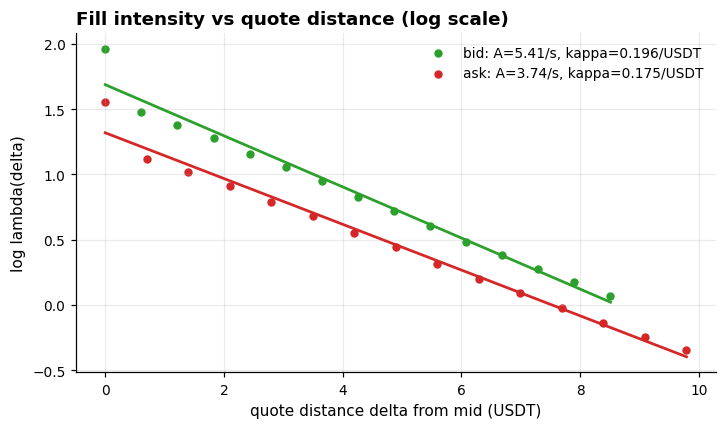

buyer-maker fraction (market sells hitting bids): 0.623


In [5]:
mid_at = markout._mid_at(t_mid, mid, trades.time.to_numpy())   # causal: strictly-prior-bin mid
ok = np.isfinite(mid_at)
bid_d, ask_d = calibrate.trade_depths(trades.price.to_numpy()[ok], mid_at[ok],
                                      trades.is_buyer_maker.to_numpy()[ok])
dur = float(trades.time.max() - trades.time.min())

fig, ax = plt.subplots(figsize=(7.5, 4.0))
fits = {}
for d, name, col in [(bid_d, 'bid', CLR['bid']), (ask_d, 'ask', CLR['ask'])]:
    A, k, x, lam = calibrate.fit_intensity(d, dur, calibrate.default_delta_grid(d))
    fits[name] = (A, k)
    ax.scatter(x, np.log(lam), s=20, color=col, label=f'{name}: A={A:.2f}/s, kappa={k:.3f}/USDT')
    ax.plot(x, np.log(A) - k*x, color=col, lw=1.8)
ax.set_xlabel('quote distance delta from mid (USDT)'); ax.set_ylabel('log lambda(delta)')
ax.set_title('Fill intensity vs quote distance (log scale)'); ax.legend(); plt.show()
print('buyer-maker fraction (market sells hitting bids):', round(float(trades.is_buyer_maker.mean()), 3))

Two honest caveats on this fit:

- **The bid/ask asymmetry** (`A` differs by ~40% between sides) is not noise to average
  away: 64% of aggressor trades are market *sells* (buyer-is-maker), so bids are hit more
  often — an order-flow imbalance over these three days — and the causal-proxy lag biases
  the two sides slightly differently. `kappa` is similar across sides; the `A` gap is the
  flow imbalance.
- **The absolute `kappa` (~0.19/USDT) is proxy-limited and implausibly low.** Because the
  1s proxy can't see the true spread, the "penetration depths" are dominated by ~1s of
  volatility (mean depth ~4 USDT, vs a 0.01 USDT tick), which flattens the fitted `kappa`.
  We use `A`, `kappa` to *calibrate the simulator* below, but a reliable fill-elasticity
  needs true quotes (`bookTicker`), not a trade-price proxy. This caveat drives the
  close-the-loop conclusion.

## 3b — Markouts: the empirical heart

For each trade, signed from the **passive** maker's point of view,

$$\text{markout}(h) = (\text{mid}_{t+h} - \text{fill}) \times (+1\ \text{if the maker bought},\ -1\ \text{if sold})$$

averaged across trades and reported in **basis points**.

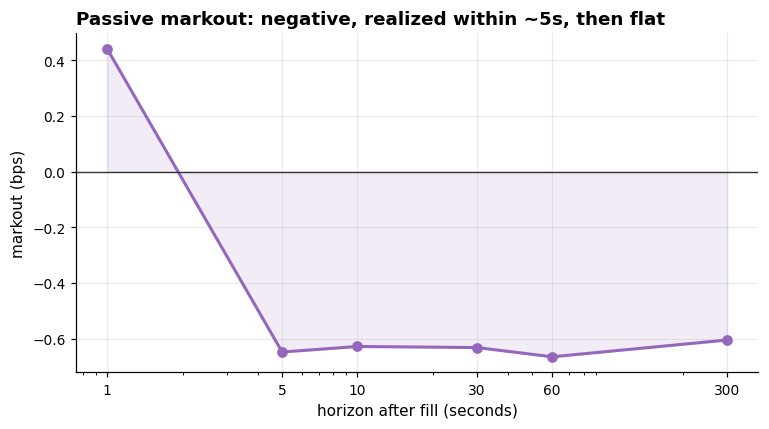

  markout @    1s = +0.441 bps   (n=3,937,198)
  markout @    5s = -0.648 bps   (n=3,937,184)
  markout @   10s = -0.629 bps   (n=3,937,157)
  markout @   30s = -0.632 bps   (n=3,937,052)
  markout @   60s = -0.666 bps   (n=3,936,859)
  markout @  300s = -0.605 bps   (n=3,935,389)


In [6]:
means, counts = markout.markout_curve(trades.time.to_numpy(), trades.price.to_numpy(),
                                     trades.is_buyer_maker.to_numpy(), t_mid, mid, HORIZONS)
fig, ax = plt.subplots(figsize=(8, 4.0))
y = [means[h] for h in HORIZONS]
ax.plot(HORIZONS, y, 'o-', color=CLR['markout'], lw=2)
ax.fill_between(HORIZONS, y, 0, color=CLR['markout'], alpha=0.12)
ax.axhline(0, color='#333', lw=0.9)
ax.set_xscale('log'); ax.set_xticks(HORIZONS); ax.set_xticklabels([str(h) for h in HORIZONS])
ax.set_xlabel('horizon after fill (seconds)'); ax.set_ylabel('markout (bps)')
ax.set_title('Passive markout: negative, realized within ~5s, then flat'); plt.show()
for h in HORIZONS:
    print(f'  markout @ {h:>4}s = {means[h]:+.3f} bps   (n={counts[h]:,})')

**What the curve actually shows** (Fix to the original claim):

- At **1s it is slightly positive** (+0.44 bps). That is *not* the maker winning — it is
  the causal proxy's ~1s lag: `mid_{t+1}` is still essentially the mid at fill time, so
  the maker just looks up by the half-spread it earned. The 1s point is a proxy artefact
  and should not be read as adverse selection.
- By **5s it is firmly negative (~−0.65 bps) and then plateaus flat out to 300s.** Adverse
  selection is essentially *fully realized within a few seconds and does not keep
  accumulating*. Going in, the textbook expectation was a curve that worsens monotonically;
  the flat plateau is what the data show — and it is a *better* number, because it bounds
  how long a maker has to react (~5s) before the informed move is complete.

The magnitude (~0.65 bps) is the robust empirical result of this project. What it does
*not* let us do is compare it to "the spread captured": the trade proxy can't measure the
true spread, so any spread-vs-markout ratio would be measuring volatility, not economics.

## 3c — Close the loop

Feed the measured adverse selection back into the simulator as a post-fill drift against
the maker, calibrated to the `sigma`, `A`, `kappa` above. Because the *timing* of that
drift is a genuine modelling choice (does the whole move land on the fill, or arrive over
several seconds?), we report a **sensitivity** over `adverse_steps` rather than one cell.
Naive and AS quote the same flat spread, as in notebook 01.

In [7]:
A_bar = 0.5*(fits['bid'][0] + fits['ask'][0])
k_bar = 0.5*(fits['bid'][1] + fits['ask'][1])
adverse = abs(means[60]) * 1e-4 * S0                 # 60s markout, in price units
gamma = 0.001
tau = 600.0
naive_half = 0.5 * float(strategies.optimal_spread(gamma, sigma_hat, k_bar, tau))
common = dict(S0=S0, sigma=sigma_hat, A=A_bar, kappa=k_bar, T=tau, dt=1.0, n_paths=3000)
print(f'calibrated sim: sigma={sigma_hat:.2f}, A={A_bar:.2f}, kappa={k_bar:.3f}; '
      f'matched half-spread={naive_half:.2f} USDT; adverse={adverse:.2f} USDT/fill')

def run_pair(K):
    rn = simulate.run(strategies.Naive(naive_half), rng=get_rng(7), adverse=adverse, adverse_steps=K, **common)
    ra = simulate.run(strategies.AvellanedaStoikov(gamma, sigma_hat, k_bar, tau), rng=get_rng(7), adverse=adverse, adverse_steps=K, **common)
    return metrics.summary('Naive', rn), metrics.summary('AS', ra)

rows = []
for K in [None, 1, 5, 30, 60]:
    if K is None:
        rn = simulate.run(strategies.Naive(naive_half), rng=get_rng(7), adverse=0.0, **common)
        ra = simulate.run(strategies.AvellanedaStoikov(gamma, sigma_hat, k_bar, tau), rng=get_rng(7), adverse=0.0, **common)
        sn, sa = metrics.summary('Naive', rn), metrics.summary('AS', ra)
        tag = 'no adverse'
    else:
        sn, sa = run_pair(K)
        tag = f'adverse, steps={K}'
    for s in (sn, sa):
        rows.append({'case': tag, 'strategy': s['strategy'], 'mean_pnl': s['mean_pnl'],
                     'pnl_sharpe': s['pnl_sharpe'], 'std_pnl': s['std_pnl'],
                     'term_inv_std': s['term_inv_std']})
loop = pd.DataFrame(rows).set_index(['case', 'strategy'])
style_table(loop.style.format('{:.1f}'),
            'Close the loop: measured adverse selection fed back in. '
            'pnl_sharpe = cross-path, per 600s run, NOT annualised.')

calibrated sim: sigma=2.16, A=4.58, kappa=0.186; matched half-spread=6.78 USDT; adverse=2.84 USDT/fill


In [8]:
# The single most important comparison: what does adverse selection actually cost each?
base = {s['strategy']: s for s in [metrics.summary('Naive', simulate.run(strategies.Naive(naive_half), rng=get_rng(7), adverse=0.0, **common)),
                                   metrics.summary('AS', simulate.run(strategies.AvellanedaStoikov(gamma, sigma_hat, k_bar, tau), rng=get_rng(7), adverse=0.0, **common))]}
sn, sa = run_pair(1)
for s, b in [(sn, base['Naive']), (sa, base['AS'])]:
    drop = s['mean_pnl'] - b['mean_pnl']
    print(f"{s['strategy']:5s}: adverse cost {drop:+7.0f} USDT ({100*drop/b['mean_pnl']:+.0f}% of PnL), "
          f"PnL std {s['std_pnl']:.0f}")
print(f"\nAS PnL std is {sn['std_pnl']/sa['std_pnl']:.1f}x smaller than naive's -> that, not cost avoidance, is AS's edge.")

Naive: adverse cost    -663 USDT (-11% of PnL), PnL std 754
AS   : adverse cost    -378 USDT (-7% of PnL), PnL std 133

AS PnL std is 5.7x smaller than naive's -> that, not cost avoidance, is AS's edge.


## What actually happened — reported as measured

- **Naive does *not* lose.** Under the causal calibration, adverse selection dents naive's
  PnL by ~10% and knocks its (per-600s, cross-path) Sharpe from ~10 to ~7, but it stays
  firmly profitable at every spread. The original "naive is a losing business, shown with
  data" headline was an artefact of the mid-proxy lookahead bug, and it does not survive a
  causal measurement. Reported honestly, per the project's own rules.
- **Adverse selection costs both strategies a *comparable* amount per fill** (naive ~−10%,
  AS ~−7%). AS does not "avoid" adverse selection — it absorbs most of the same hit.
- **AS's real advantage is variance.** Its PnL standard deviation is several times smaller
  than naive's because inventory control removes the mark-to-market swings; that is what
  drives the Sharpe gap, and it is a *different thing* from avoiding adverse selection.
- **The result's size depends on how fast the maker can flatten** relative to how fast the
  adverse move arrives — which is exactly what the `adverse_steps` sensitivity shows: naive
  is stable across it, while AS's mean-PnL protection grows as the move is spread out.
- **A definitive verdict on naive's profitability needs true quotes.** The trade proxy
  cannot measure the spread the maker earns (only volatility), so it cannot pin the
  spread-vs-adverse economics. That would need `bookTicker`, and is honest future work.

Two caveats worth saying out loud (also in the README): the markout is measured on **all**
tape trades, not this strategy's own fills, so it estimates the adverse selection facing a
*typical* passive quote; and the feedback injects it as a first-order per-fill drift, not a
microstructurally exact coupling.